<a href="https://colab.research.google.com/github/reynaudnangue28/test/blob/main/CO2_Emission_Project_Data_Visualizations_EEA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


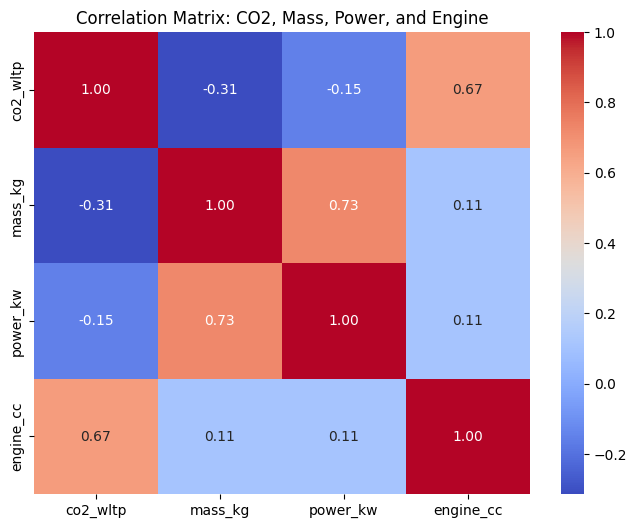

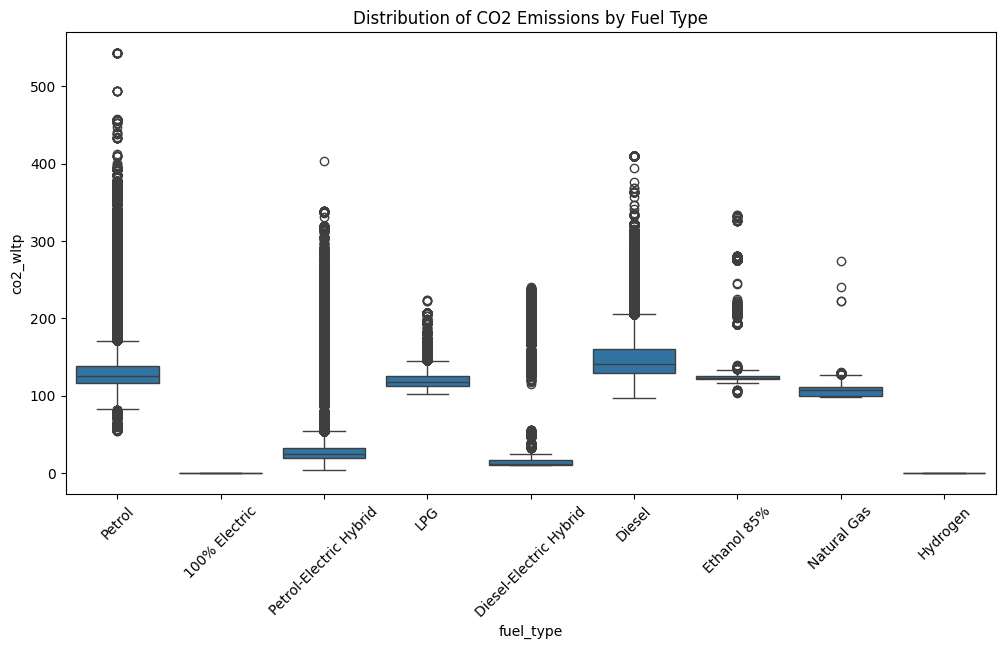

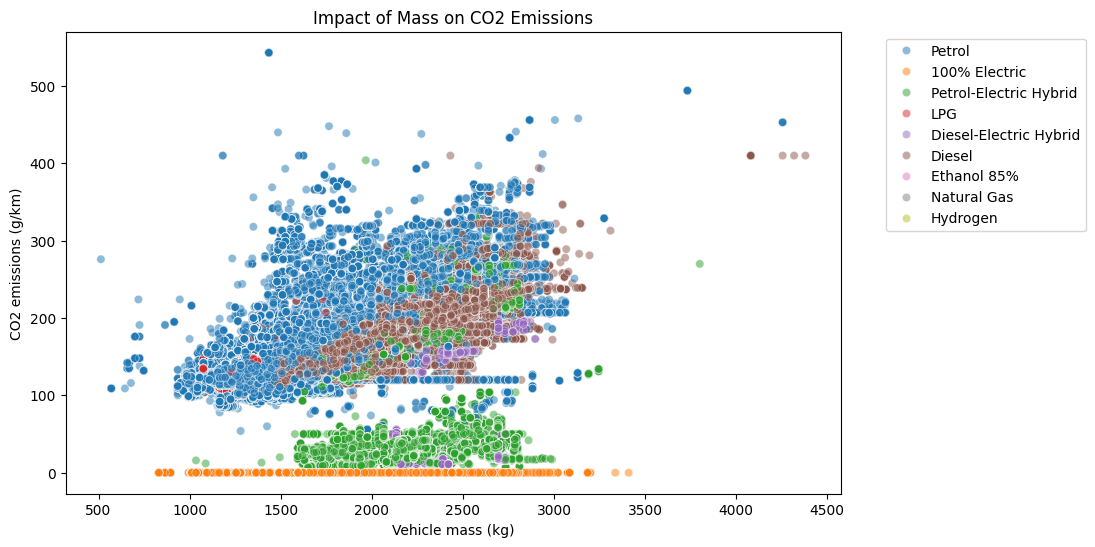

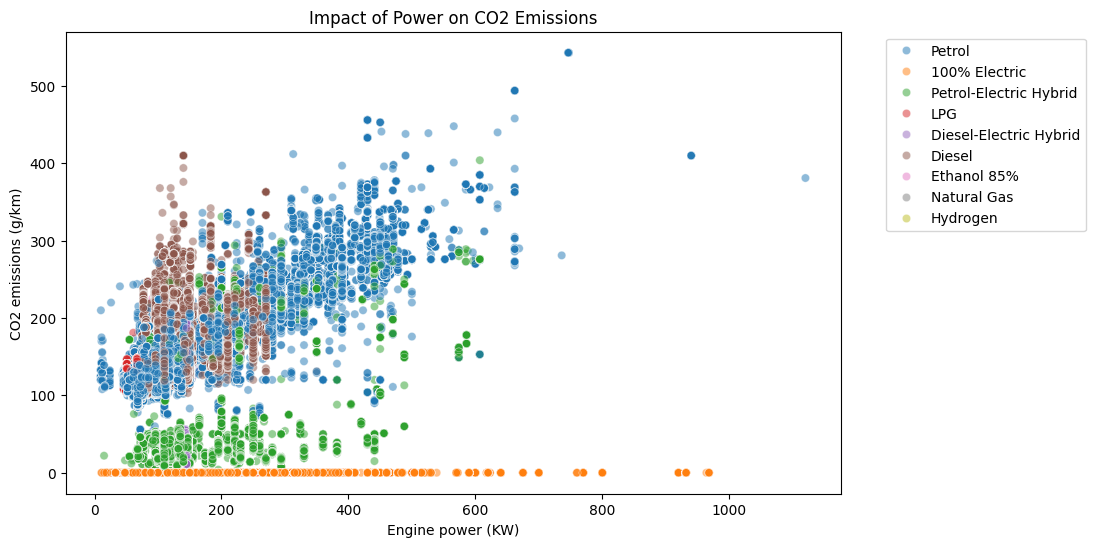

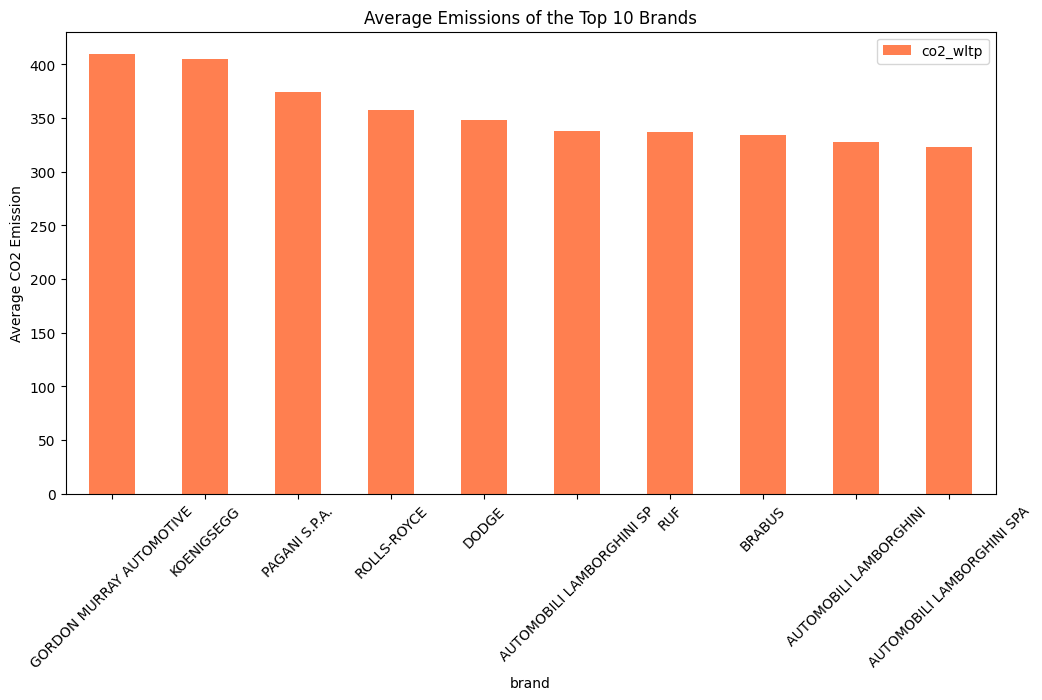

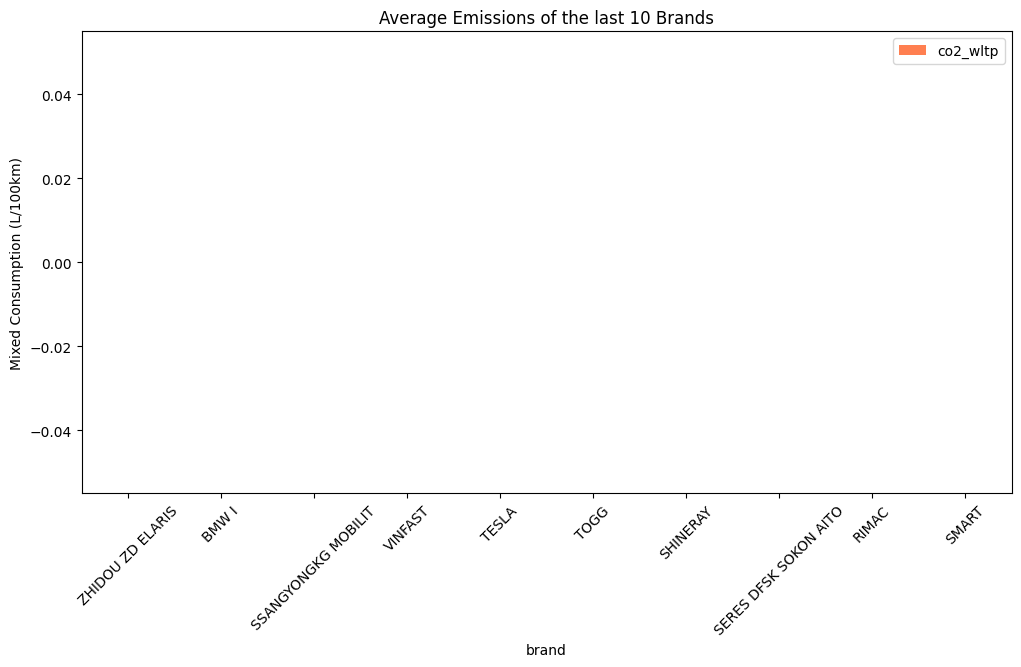

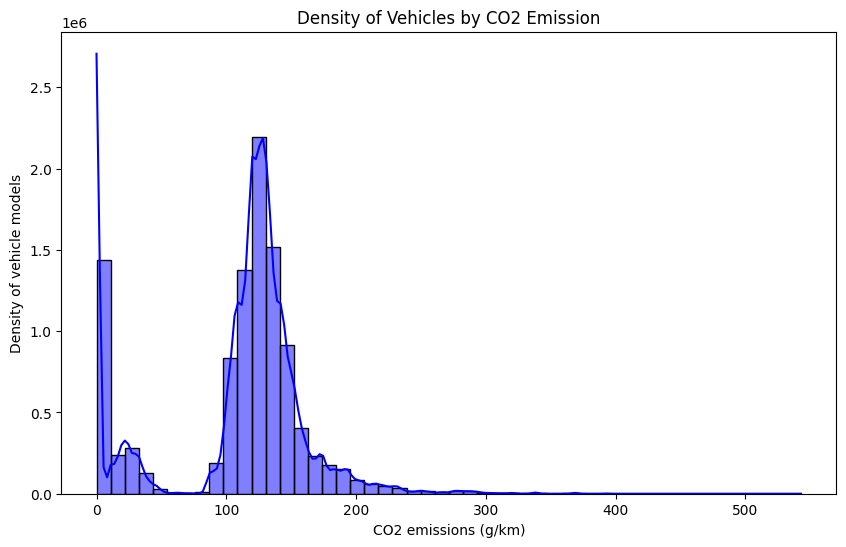

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Google Colab to access and mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---  load a mapping csv---
try:
    mapping_df = pd.read_csv('/content/drive/MyDrive/Data/EEA2024CO2Data/eea_column_mapping.csv')
    cols_to_keep = mapping_df[mapping_df['keep'] == True]
    rename_map = dict(zip(cols_to_keep['column_name_original'], cols_to_keep['column_name_new']))
except FileNotFoundError:
    print("Error : file is missing.")
    exit()

# ---  load the EEA file  ---

df1 = pd.read_csv(
    "/content/drive/MyDrive/Data/EEA2024CO2Data/data.csv",
    nrows=7000000,
    low_memory=False
)

#Reading Between Raws 7 million and 10.8 million

df2 = pd.read_csv(
    "/content/drive/MyDrive/Data/EEA2024CO2Data/data.csv",
    skiprows=range(1, 7_000_001),  # skip header + first 7M rows
    low_memory=False
)

# ---  Filter and rename ---
# choose only the columns with 'keep=True'
df1 = df1[rename_map.keys()]
# Rename the columns
df1 = df1.rename(columns=rename_map)

# choose only the columns with 'keep=True'
df2 = df2[rename_map.keys()]
# Rename the columns
df2 = df2.rename(columns=rename_map)

#Concat of df1 and df2
df = pd.concat([df1, df2], axis=0, ignore_index=True)

# ---  end ---

fuel_map   = {
    'petrol': "Petrol",
    'diesel': "Diesel",
    'petrol/electric': "Petrol-Electric Hybrid",
    'diesel/electric': "Diesel-Electric Hybrid",
    'electric': "100% Electric",
    'lpg': "LPG",
    'ng': "Natural Gas",
    'e85': "Ethanol 85%",
    'hydrogen': "Hydrogen",
    'unknown': "Unknown",
    'es': "Petrol"
}

df['fuel_type'] = df['fuel_type'].str.strip().str.lower().replace(fuel_map)

#  Basic Preprocessing

#numeric features
features = [
    "mass_kg",
    "wltp_mass_kg",
    "engine_cc",
    "power_kw",
    "electric_consumption",
    "fuel_type"
]
target = 'co2_wltp'

df['engine_cc'] = df['engine_cc'].fillna(0)


df['electric_consumption'] = df['electric_consumption'].fillna(0)

# Drop rows with missing values in these specific columns
df = df.dropna(subset=features + [target])

#Graphical presentations


# This helps you see if higher power (puiss_max) correlates with higher pollutants like nox
#Select only the relevant numeric columns
plt.figure(figsize=(8, 6))
cols_to_correlate = ['co2_wltp', 'mass_kg',"power_kw", 'engine_cc']
correlation_matrix = df[cols_to_correlate].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: CO2, Mass, Power, and Engine')
plt.show()

#Unlike a simple average, this shows the spread and outliers.
#You can see if certain "Green" brands actually have high-emission outliers in their catalog
plt.figure(figsize=(12, 6))
sns.boxplot(x='fuel_type', y='co2_wltp', data=df)
plt.xticks(rotation=45)
plt.title('Distribution of CO2 Emissions by Fuel Type')
plt.show()

#This scatter plot identifies how weight affects emissions across different fuel types.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='mass_kg', y='co2_wltp',hue='fuel_type', alpha=0.5)
plt.title('Impact of Mass on CO2 Emissions')
plt.xlabel('Vehicle mass (kg)')
plt.ylabel('CO2 emissions (g/km)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#This scatter plot identifies how power affects emissions across different fuel types.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='power_kw', y='co2_wltp',hue='fuel_type', alpha=0.5)
plt.title('Impact of Power on CO2 Emissions')
plt.xlabel('Engine power (KW)')
plt.ylabel('CO2 emissions (g/km)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Identify which manufacturers had the lowest average fuel consumption
plt.figure(figsize=(12, 6))
brand_means = df.groupby('brand')['co2_wltp'].mean().sort_values(ascending=False).head(10)
brand_means.plot(kind='bar', color='coral')
#plt.axhline(y=95, color='green', linestyle='--', label='Cible UE 2026 (~95g/km)')
plt.title('Average Emissions of the Top 10 Brands')
plt.ylabel('Average CO2 Emission')
plt.xticks(rotation=45)
plt.legend()
plt.show()


# Identify which manufacturers had the lowest average fuel consumption
plt.figure(figsize=(12, 6))
brand_means = df.groupby('brand')['co2_wltp'].mean().sort_values(ascending=True).head(10)
brand_means.plot(kind='bar', color='coral')
#plt.axhline(y=95, color='green', linestyle='--', label='Cible UE 2026 (~95g/km)')
plt.title('Average Emissions of the last 10 Brands')
plt.ylabel('Mixed Consumption (L/100km)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

#It pinpoints the most common emission levels (the "peak") to see where 2024 engine technology was most concentrated
plt.figure(figsize=(10, 6))
sns.histplot(df['co2_wltp'].dropna(), kde=True, color='blue', bins=50)
plt.title('Density of Vehicles by CO2 Emission')
plt.xlabel('CO2 emissions (g/km)')
plt.ylabel('Density of vehicle models')
plt.show()
